In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [202]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # Import for custom grid layout
from sklearn.model_selection import KFold
import pickle

from notebooks.imports import *
from config import dir_config
from src.utils import pmf_utils, glm_hmm_utils

In [3]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [ ]:
with open(Path(processed_dir, 'sessions_metadata.csv'), 'r') as f:
    session_metadata = pd.read_csv(f)

## Prepare data

In [99]:

# Pre-allocate lists for session data
behavior_df = pd.DataFrame(columns=["session_id", "prior_direction", "GP_trial_num", "prob_toRF", "signed_coherence", "target", "choice", "outcome","response_time"])


# Process each session
for _, session_row in session_metadata.iterrows():

    session_id = session_row["session_id"]
    prior_direction = "L" if (session_row["prior_direction"] == "toRF" and session_row["RF_side"] == "L") or (session_row["prior_direction"] == "awayRF" and session_row["RF_side"] == "R") else "R"

    # Read trial data for each session
    trial_data = pd.read_csv(Path(compiled_dir, session_id, f"{session_id}_trial.csv"), index_col=None)
    GP_trial_data = trial_data[trial_data.task_type == 1].reset_index()


    # Get valid indices based on outcomes
    valid_idx = np.where(GP_trial_data.outcome >= 0)[0]

    coherence = GP_trial_data.coherence.values[valid_idx]
    target = GP_trial_data.target.values[valid_idx].astype("int")
    choices = GP_trial_data.choice.values[valid_idx].astype("int")
    outcomes = GP_trial_data.outcome.values[valid_idx].astype("int")

    if session_row["RF_side"] == "L": # flip target and choice to L/R as 0/1
        target = 1 - target
        choices = 1 - choices

    signed_coherence = coherence * (target * 2 - 1)
    GP_trial_num = np.array(GP_trial_data.trial_number)[valid_idx]
    prob_toRF = np.array(GP_trial_data.prob_toRF)[valid_idx]


    behavior_df = pd.concat([behavior_df, pd.DataFrame({
        "session_id": session_id,
        "prior_direction": prior_direction,
        "GP_trial_num": GP_trial_num,
        "prob_toRF": prob_toRF,
        "signed_coherence": signed_coherence,
        "target": target,
        "choice": choices,
        "outcome": outcomes,
        "response_time": GP_trial_data.reaction_time.values[valid_idx]
    })], ignore_index=True)


#### utils

In [53]:
def psychometric_fit(stimulus, choices, expected_choice_prob, ax, color, label, n_sample=10):
	data = {"signed_coherence": np.array(stimulus) * 100, "choice": choices}
	x_data, y_data, model, x_model, y_model = pmf_utils.get_psychometric_data(data)

	x_model_hat, y_model_hat = np.full((n_sample, len(x_model)), np.nan), np.full((n_sample, len(y_model)), np.nan)

	ax.plot(x_data, y_data, "o", color=color)
	ax.plot(x_model, y_model, color=color, label=label)
	ax.plot(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0), color=color, linestyle="--")
	ax.fill_between(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0) - np.std(y_model_hat, axis=0), np.mean(y_model_hat, axis=0) + np.std(y_model_hat, axis=0), color=color, alpha=0.3)

	ax.set_xlim(min(x_data), max(x_data))
	ax.set_xlabel("Coherence")
	ax.set_ylabel("choices toRF")
	ax.set_title("Psychometric fits", fontsize=15)
	ax.legend()

### PMF

In [302]:
left_sessions, right_sessions = 0,0

for session_id in session_metadata["session_id"]:
    session_data = behavior_df[behavior_df.session_id == session_id]

    if session_data.empty:
        continue  # Skip if no data

    equal_data = session_data[session_data.prob_toRF == 50]
    unequal_data = session_data[session_data.prob_toRF != 50]

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]
    if prior_dir == "L":
        left_sessions += 1
    elif prior_dir == "R":
        right_sessions += 1
left_sessions, right_sessions

(24, 21)

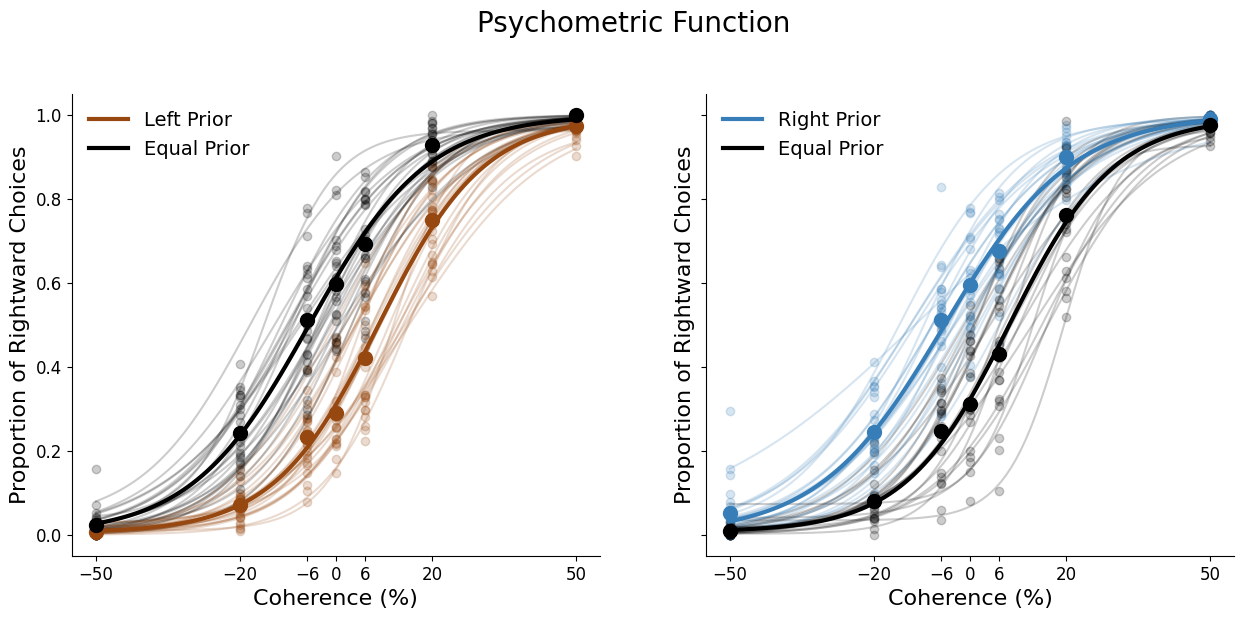

In [303]:
import matplotlib.pyplot as plt

alpha_value = 0.2
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

eq_left_model, uneq_left_model = {'alpha': [], 'beta': [], 'lapse_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': []}
eq_right_model, uneq_right_model = {'alpha': [], 'beta': [], 'lapse_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': []}

for session_id in session_metadata["session_id"]:
    session_data = behavior_df[behavior_df.session_id == session_id]

    if session_data.empty:
        continue  # Skip if no data

    equal_data = session_data[session_data.prob_toRF == 50]
    unequal_data = session_data[session_data.prob_toRF != 50]

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]
    color = uneq_color.get(prior_dir)

    # Get psychometric data
    x_eq_data, y_eq_data, eq_model, x_eq_model, y_eq_model = pmf_utils.get_psychometric_data(equal_data, model_type='logit_3')
    x_uneq_data, y_uneq_data, uneq_model, x_uneq_model, y_uneq_model = pmf_utils.get_psychometric_data(unequal_data, model_type='logit_3')


    if prior_dir == "L":
        ax = axs[0]
        eq_left_model['alpha'].append(eq_model.coefs_['mean'])
        eq_left_model['beta'].append(eq_model.coefs_['var'])
        eq_left_model['lapse_rate'].append(eq_model.coefs_['lapse_rate'])
        uneq_left_model['alpha'].append(uneq_model.coefs_['mean'])
        uneq_left_model['beta'].append(uneq_model.coefs_['var'])
        uneq_left_model['lapse_rate'].append(uneq_model.coefs_['lapse_rate'])
    else:
        ax = axs[1]
        eq_right_model['alpha'].append(eq_model.coefs_['mean'])
        eq_right_model['beta'].append(eq_model.coefs_['var'])
        eq_right_model['lapse_rate'].append(eq_model.coefs_['lapse_rate'])
        uneq_right_model['alpha'].append(uneq_model.coefs_['mean'])
        uneq_right_model['beta'].append(uneq_model.coefs_['var'])
        uneq_right_model['lapse_rate'].append(uneq_model.coefs_['lapse_rate'])

    ax.plot(x_uneq_data, y_uneq_data, "o", color=color, alpha=alpha_value)
    ax.plot(x_uneq_model, y_uneq_model, linestyle="-", color=color, alpha=alpha_value)
    ax.plot(x_eq_data, y_eq_data, "o", color=eq_color, alpha=alpha_value)
    ax.plot(x_eq_model, y_eq_model, color=eq_color, alpha=alpha_value)

left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

x_left_eq_data, y_left_eq_data, _, x_left_eq_model, y_left_eq_model = pmf_utils.get_psychometric_data(left_prior_data[left_prior_data.prob_toRF == 50], model_type='logit_3')
x_left_uneq_data, y_left_uneq_data, _, x_left_uneq_model, y_left_uneq_model = pmf_utils.get_psychometric_data(left_prior_data[left_prior_data.prob_toRF != 50], model_type='logit_3')

x_right_eq_data, y_right_eq_data, _, x_right_eq_model, y_right_eq_model = pmf_utils.get_psychometric_data(right_prior_data[right_prior_data.prob_toRF == 50], model_type='logit_3')
x_right_uneq_data, y_right_uneq_data, _, x_right_uneq_model, y_right_uneq_model = pmf_utils.get_psychometric_data(right_prior_data[right_prior_data.prob_toRF != 50], model_type='logit_3')

axs[0].plot(x_left_eq_data, y_left_uneq_data, "o", color=uneq_color["L"], markersize =10)
axs[0].plot(x_left_uneq_model, y_left_uneq_model, linestyle="-", color=uneq_color["L"],linewidth=3, label="Left Prior")
axs[0].plot(x_left_eq_data, y_left_eq_data, "o", color=eq_color, markersize =10)
axs[0].plot(x_left_eq_model, y_left_eq_model, color=eq_color,linewidth=3, label="Equal Prior")

axs[1].plot(x_right_eq_data, y_right_uneq_data, "o", color=uneq_color["R"], markersize =10)
axs[1].plot(x_right_uneq_model, y_right_uneq_model, linestyle="-", color=uneq_color["R"],linewidth=3, label="Right Prior")
axs[1].plot(x_right_eq_data, y_right_eq_data, "o", color=eq_color, markersize =10)
axs[1].plot(x_right_eq_model, y_right_eq_model, color=eq_color,linewidth=3, label="Equal Prior")

for ax in axs:
    ax.set_xticks([-50,-20,-6,0,6,20,50])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel('Coherence (%)',fontsize=16)
    ax.set_ylabel('Proportion of Rightward Choices',fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=14,frameon=False)

# axs[0].set_title("Left Prior Sessions", fontsize=20, pad=30)
# axs[1].set_title("Right Prior Sessions", fontsize=20, pad=30)

plt.suptitle("Psychometric Function",fontsize=20, y=1.02);


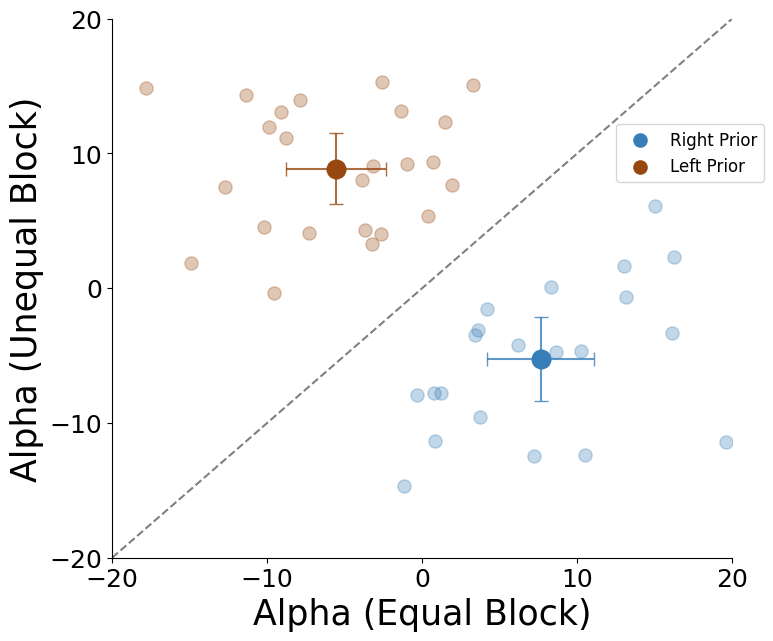

In [304]:
plt.figure(figsize=(8,7))

range = ([-20,20])

plt.scatter(eq_left_model['alpha'],uneq_left_model['alpha'],color=uneq_color["L"], s=90, alpha=0.3)
plt.scatter(eq_right_model['alpha'],uneq_right_model['alpha'],color=uneq_color["R"], s=90, alpha=0.3)# Left Prior Mean and Error
mean_eq_left = np.mean(eq_left_model['alpha'])
mean_uneq_left = np.mean(uneq_left_model['alpha'])
sem_eq_left = np.std(eq_left_model['alpha']) / np.sqrt(len(eq_left_model))
sem_uneq_left = np.std(uneq_left_model['alpha']) / np.sqrt(len(uneq_left_model))

plt.scatter(mean_eq_left, mean_uneq_left, color=uneq_color["L"], s=180)
plt.errorbar(mean_eq_left, mean_uneq_left,
             xerr=sem_eq_left, yerr=sem_uneq_left,
             fmt='o', color=uneq_color["L"], capsize=5, alpha=0.8)

# Right Prior Mean and Error
mean_eq_right = np.mean(eq_right_model['alpha'])
mean_uneq_right = np.mean(uneq_right_model['alpha'])
sem_eq_right = np.std(eq_right_model['alpha']) / np.sqrt(len(eq_right_model))
sem_uneq_right = np.std(uneq_right_model['alpha']) / np.sqrt(len(uneq_right_model))

plt.scatter(mean_eq_right, mean_uneq_right, color=uneq_color["R"], s=180)
plt.errorbar(mean_eq_right, mean_uneq_right,
             xerr=sem_eq_right, yerr=sem_uneq_right,
             fmt='o', color=uneq_color["R"], capsize=5, alpha=0.8)



plt.scatter([], [], color=uneq_color["R"], label="Right Prior", s=90)
plt.scatter([], [], color=uneq_color["L"], label = "Left Prior", s=90)
plt.xlim(range)
plt.ylim(range)
plt.plot(range,range,color='gray',linestyle='--')
plt.xticks(np.arange(range[0],range[1]+1,10))
plt.yticks(np.arange(range[0],range[1]+1,10))
plt.tick_params(axis='both', labelsize=18)
plt.xlabel('Alpha (Equal Block)',fontsize=25)
plt.ylabel('Alpha (Unequal Block)',fontsize=25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(bbox_to_anchor=(0.8 , 0.82), loc='upper left', fontsize=12, frameon=True);


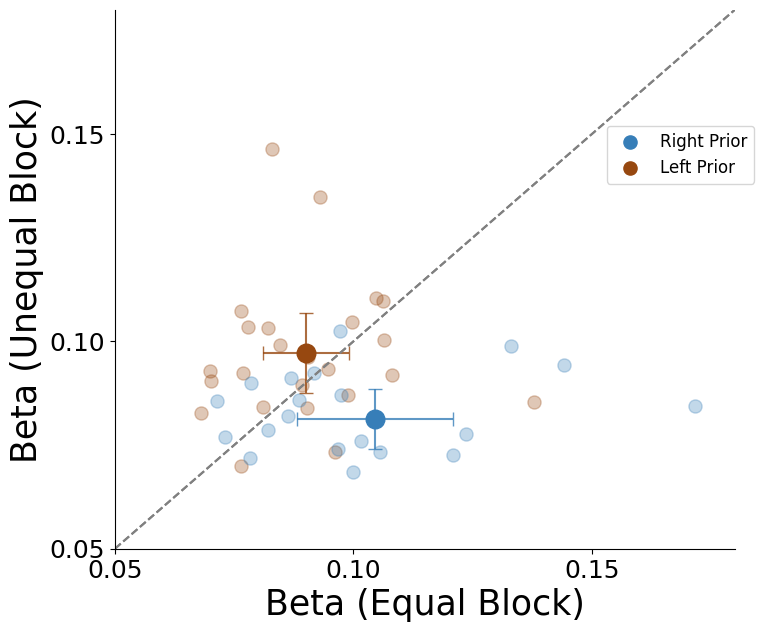

In [306]:
plt.figure(figsize=(8,7))
range = tuple([0.05,0.18])
plt.scatter(eq_left_model['beta'],uneq_left_model['beta'],color=uneq_color["L"], s=90, alpha=0.3)
plt.scatter(eq_right_model['beta'],uneq_right_model['beta'],color=uneq_color["R"], s=90, alpha=0.3)
mean_eq_left = np.mean(eq_left_model['beta'])
mean_uneq_left = np.mean(uneq_left_model['beta'])
sem_eq_left = np.std(eq_left_model['beta']) / np.sqrt(len(eq_left_model))
sem_uneq_left = np.std(uneq_left_model['beta']) / np.sqrt(len(uneq_left_model))

plt.scatter(mean_eq_left, mean_uneq_left, color=uneq_color["L"], s=180)
plt.errorbar(mean_eq_left, mean_uneq_left,
             xerr=sem_eq_left, yerr=sem_uneq_left,
             fmt='o', color=uneq_color["L"], capsize=5, alpha=0.8)

# Right Prior Mean and Error
mean_eq_right = np.mean(eq_right_model['beta'])
mean_uneq_right = np.mean(uneq_right_model['beta'])
sem_eq_right = np.std(eq_right_model['beta']) / np.sqrt(len(eq_right_model))
sem_uneq_right = np.std(uneq_right_model['beta']) / np.sqrt(len(uneq_right_model))

plt.scatter(mean_eq_right, mean_uneq_right, color=uneq_color["R"], s=180)
plt.errorbar(mean_eq_right, mean_uneq_right,
             xerr=sem_eq_right, yerr=sem_uneq_right,
             fmt='o', color=uneq_color["R"], capsize=5, alpha=0.8)


plt.xlim(range)
plt.ylim(range)
plt.plot(range,range,color='gray',linestyle='--')
plt.xticks(np.arange(range[0], range[1]+0.01, 0.05))
plt.yticks(np.arange(range[0], range[1]+0.01, 0.05))

plt.scatter([], [], color=uneq_color["R"], s=90, label="Right Prior")
plt.scatter([], [], color=uneq_color["L"], s=90, label="Left Prior")
plt.xlim(range)
plt.ylim(range)
plt.plot(range,range,color='gray',linestyle='--')

plt.tick_params(axis='both', labelsize=18)
plt.xlabel('Beta (Equal Block)',fontsize=25)
plt.ylabel('Beta (Unequal Block)',fontsize=25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(bbox_to_anchor=(0.78 , 0.8), loc='upper left', fontsize=12, frameon=True);


## Chronometric functions

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


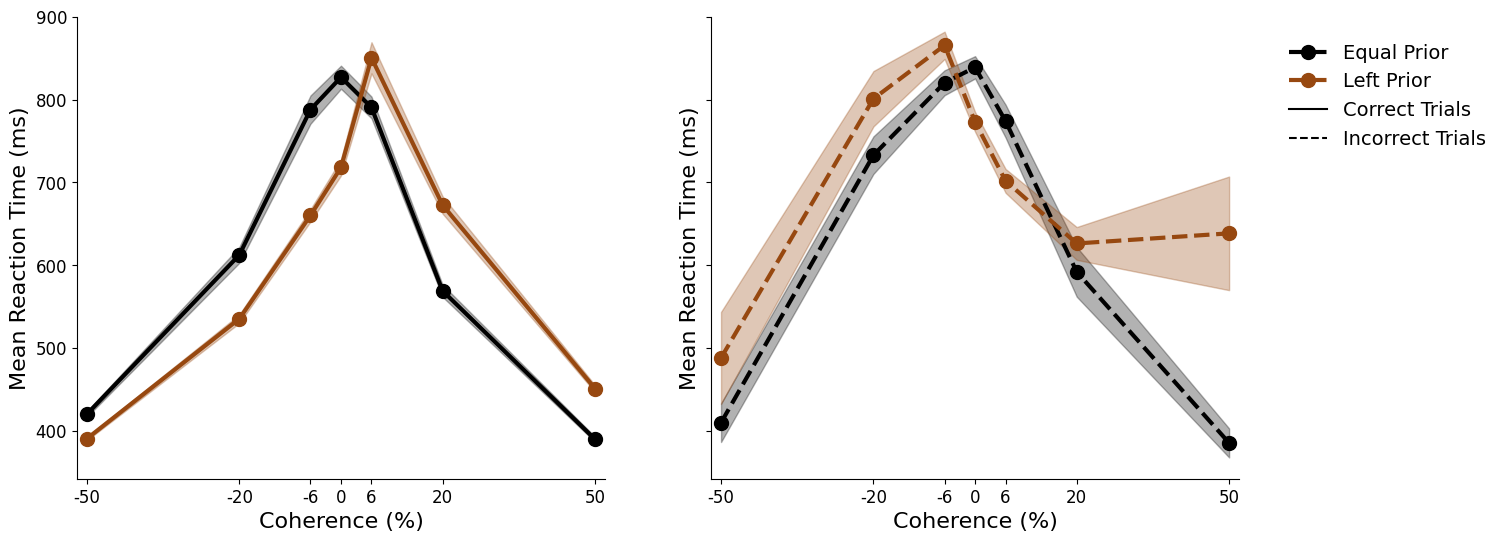

In [ ]:

alpha_value = 0.2
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

left_eq_corr_coherences, _, left_eq_corr_rt_mean, _, left_eq_corr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF == 50])
left_uneq_corr_coherences, _, left_uneq_corr_rt_mean, _, left_uneq_corr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF != 50])

left_eq_incorr_coherences, _, left_eq_incorr_rt_mean, _, left_eq_incorr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF == 50], outcome=0)
left_uneq_incorr_coherences, _, left_uneq_incorr_rt_mean, _, left_uneq_incorr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF != 50], outcome=0)

axs[0].plot(left_eq_corr_coherences, left_eq_corr_rt_mean, marker="o", linestyle="-",color=eq_color, markersize =10,linewidth=3)
axs[0].plot(left_uneq_corr_coherences, left_uneq_corr_rt_mean, marker="o", linestyle="-", color=uneq_color["L"],markersize =10,linewidth=3)
axs[0].fill_between(left_eq_corr_coherences, left_eq_corr_rt_mean - left_eq_corr_rt_sem, left_eq_corr_rt_mean + left_eq_corr_rt_sem, color=eq_color, alpha=0.3)
axs[0].fill_between(left_uneq_corr_coherences, left_uneq_corr_rt_mean - left_uneq_corr_rt_sem, left_uneq_corr_rt_mean + left_uneq_corr_rt_sem, color=uneq_color["L"], alpha=0.3)


axs[1].plot(left_eq_incorr_coherences, left_eq_incorr_rt_mean, marker="o", linestyle="--",color=eq_color, markersize =10,linewidth=3,label="Equal Prior")
axs[1].plot(left_uneq_incorr_coherences, left_uneq_incorr_rt_mean, marker="o", linestyle="--", color=uneq_color["L"],markersize =10,linewidth=3, label="Left Prior")
axs[1].fill_between(left_eq_incorr_coherences, left_eq_incorr_rt_mean - left_eq_incorr_rt_sem, left_eq_incorr_rt_mean + left_eq_incorr_rt_sem, color=eq_color, alpha=0.3)
axs[1].fill_between(left_uneq_incorr_coherences, left_uneq_incorr_rt_mean - left_uneq_incorr_rt_sem, left_uneq_incorr_rt_mean + left_uneq_incorr_rt_sem, color=uneq_color["L"], alpha=0.3)

axs[1].plot([], [], linestyle="-", color='k', label="Correct Trials")
axs[1].plot([], [], linestyle="--", color='k', label="Incorrect Trials")


for ax in axs:
    ax.set_xticks([-50,-20,-6,0,6,20,50, ax.get_xlim()[1]])
    ax.set_xticklabels([-50,-20,-6,0,6,20,50, ""])
    ax.set_xlim([-52, 52])
    ax.set_ylim([ax.get_ylim()[0], 900])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel('Coherence (%)',fontsize=16)
    ax.set_ylabel('Mean Reaction Time (ms)',fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=14,frameon=False, bbox_to_anchor=(1.5, 0.98))


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


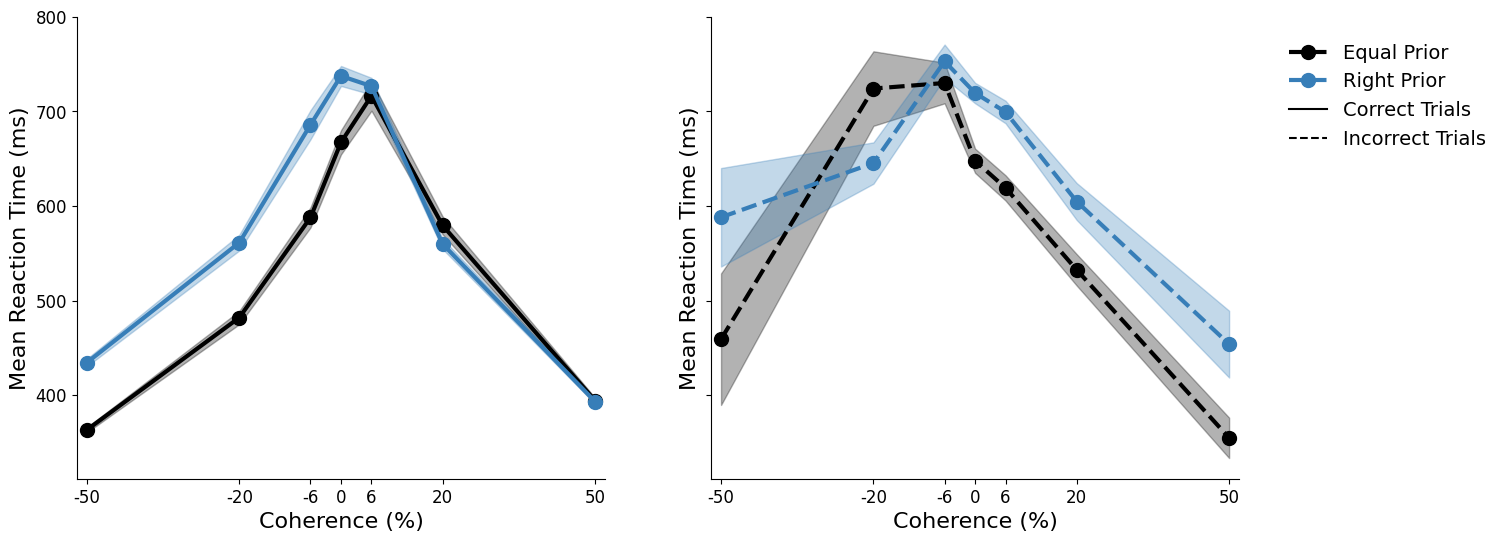

In [237]:

alpha_value = 0.2
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

right_eq_corr_coherences, _, right_eq_corr_rt_mean, _, right_eq_corr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF == 50])
right_uneq_corr_coherences, _, right_uneq_corr_rt_mean, _, right_uneq_corr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF != 50])

right_eq_incorr_coherences, _, right_eq_incorr_rt_mean, _, right_eq_incorr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF == 50], outcome=0)
right_uneq_incorr_coherences, _, right_uneq_incorr_rt_mean, _, right_uneq_incorr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF != 50], outcome=0)

axs[0].plot(right_eq_corr_coherences, right_eq_corr_rt_mean, marker="o", linestyle="-",color=eq_color, markersize =10,linewidth=3)
axs[0].plot(right_uneq_corr_coherences, right_uneq_corr_rt_mean, marker="o", linestyle="-", color=uneq_color["R"],markersize =10,linewidth=3)
axs[0].fill_between(right_eq_corr_coherences, right_eq_corr_rt_mean - right_eq_corr_rt_sem, right_eq_corr_rt_mean + right_eq_corr_rt_sem, color=eq_color, alpha=0.3)
axs[0].fill_between(right_uneq_corr_coherences, right_uneq_corr_rt_mean - right_uneq_corr_rt_sem, right_uneq_corr_rt_mean + right_uneq_corr_rt_sem, color=uneq_color["R"], alpha=0.3)


axs[1].plot(right_eq_incorr_coherences, right_eq_incorr_rt_mean, marker="o", linestyle="--",color=eq_color, markersize =10,linewidth=3,label="Equal Prior")
axs[1].plot(right_uneq_incorr_coherences, right_uneq_incorr_rt_mean, marker="o", linestyle="--", color=uneq_color["R"],markersize =10,linewidth=3, label="Right Prior")
axs[1].fill_between(right_eq_incorr_coherences, right_eq_incorr_rt_mean - right_eq_incorr_rt_sem, right_eq_incorr_rt_mean + right_eq_incorr_rt_sem, color=eq_color, alpha=0.3)
axs[1].fill_between(right_uneq_incorr_coherences, right_uneq_incorr_rt_mean - right_uneq_incorr_rt_sem, right_uneq_incorr_rt_mean + right_uneq_incorr_rt_sem, color=uneq_color["R"], alpha=0.3)

axs[1].plot([], [], linestyle="-", color='k', label="Correct Trials")
axs[1].plot([], [], linestyle="--", color='k', label="Incorrect Trials")


for ax in axs:
    ax.set_xticks([-50,-20,-6,0,6,20,50, ax.get_xlim()[1]])
    ax.set_xticklabels([-50,-20,-6,0,6,20,50, ""])
    ax.set_xlim([-52, 52])
    ax.set_ylim([ax.get_ylim()[0], 800])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel('Coherence (%)',fontsize=16)
    ax.set_ylabel('Mean Reaction Time (ms)',fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=14,frameon=False, bbox_to_anchor=(1.5, 0.98))
